# Curve fitting a heat-capacity polynomial

**A getting-started Python exercise for CHEG231 / CBET Chapter 1.**

Skills: reading data, curve fitting, and plotting — applied to a real thermodynamics task.

The ideal-gas heat capacity of a substance is tabulated in **Appendix A.II** as a cubic polynomial in temperature,

$$C_P^{*}(T) = a + b\,T + c\,T^{2} + d\,T^{3}\qquad[\mathrm{J/(mol\,K)}],\ T\ \text{in K}.$$

In this notebook we **fit that polynomial to heat-capacity data for carbon dioxide** taken from the NIST Chemistry WebBook, then **compare our fitted coefficients with the book's Appendix A.II values** for CO$_2$ (which live in the property dataset exported from the legacy companion database, `../data/pure_property.csv`).

NIST reports $C_P^{*}$ through the *Shomate* equation, a **different** functional form:

$$C_P^{*}(T) = A + B\,t + C\,t^{2} + D\,t^{3} + \frac{E}{t^{2}},\qquad t = T/1000.$$

So this is a genuine fit: we are approximating one model (Shomate, with a $1/t^2$ term) by the book's simpler cubic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Get the data (NIST Chemistry WebBook)

NIST gives the gas-phase Shomate parameters for CO$_2$ over 298–1200 K
(Chase, *NIST-JANAF Thermochemical Tables*, 1998). We evaluate them at a set of
temperatures to make a table of $(T, C_P)$ points — this is the "data" we will fit.

In [2]:
# CO2 gas-phase Shomate parameters, 298-1200 K (NIST WebBook, species C124389)
# Cp = A + B*t + C*t^2 + D*t^3 + E/t^2,  t = T/1000,  Cp in J/(mol K)
A_s, B_s, C_s, D_s, E_s = 24.99735, 55.18696, -33.69137, 7.948387, -0.136638

def cp_nist(T):
    t = np.asarray(T) / 1000.0
    return A_s + B_s*t + C_s*t**2 + D_s*t**3 + E_s/t**2

T_data  = np.arange(300.0, 1201.0, 50.0)   # K
Cp_data = cp_nist(T_data)                  # J/(mol K)

print(f"{'T (K)':>7}   {'Cp (J/mol/K)':>12}")
for T, Cp in zip(T_data, Cp_data):
    print(f"{T:7.0f}   {Cp:12.2f}")

  T (K)   Cp (J/mol/K)
    300          37.22
    350          39.41
    400          41.34
    450          43.06
    500          44.61
    550          46.03
    600          47.32
    650          48.49
    700          49.57
    750          50.55
    800          51.44
    850          52.26
    900          53.00
    950          53.68
   1000          54.30
   1050          54.88
   1100          55.40
   1150          55.89
   1200          56.35


## 2. Fit the Appendix A.II polynomial

`numpy.polyfit(x, y, 3)` returns the least-squares cubic. It orders the
coefficients from the highest power down, i.e. $[d, c, b, a]$.

In [3]:
coeffs = np.polyfit(T_data, Cp_data, 3)   # [d, c, b, a]
d, c, b, a = coeffs
cp_fit = np.poly1d(coeffs)                # callable model, cp_fit(T)

print("Fitted Appendix A.II coefficients for CO2:")
print(f"  a = {a: .5g}   J/(mol K)")
print(f"  b = {b: .5g}   J/(mol K^2)")
print(f"  c = {c: .5g}   J/(mol K^3)")
print(f"  d = {d: .5g}   J/(mol K^4)")

rmse = np.sqrt(np.mean((Cp_data - cp_fit(T_data))**2))
print(f"\nfit RMSE over 300-1200 K: {rmse:.3f} J/(mol K)")

Fitted Appendix A.II coefficients for CO2:
  a =  20.781   J/(mol K)
  b =  0.068286   J/(mol K^2)
  c = -4.7896e-05   J/(mol K^3)
  d =  1.31e-08   J/(mol K^4)

fit RMSE over 300-1200 K: 0.039 J/(mol K)


## 3. Compare with the book's Appendix A.II coefficients

The book's coefficients for CO$_2$ are read straight from the property dataset
(`CpA`–`CpD` in `pure_property.csv`). We compare two things: the **coefficients**
themselves, and the **curves** they produce.

In [4]:
props = pd.read_csv("../data/pure_property.csv")
co2 = props[props["Formula"] == "CO2"].iloc[0]
book = {"a": co2.CpA, "b": co2.CpB, "c": co2.CpC, "d": co2.CpD}

print(f"{'coef':>4}  {'fitted':>13}  {'book (A.II)':>13}  {'% diff':>7}")
for name, fit_val in zip("abcd", [a, b, c, d]):
    pct = 100*(fit_val - book[name])/book[name]
    print(f"{name:>4}  {fit_val:13.5g}  {book[name]:13.5g}  {pct:6.1f}%")

def cp_book(T):
    T = np.asarray(T)
    return book["a"] + book["b"]*T + book["c"]*T**2 + book["d"]*T**3

# Compare the CURVES, not just the coefficients:
maxdev = np.max(np.abs(cp_book(T_data) - Cp_data))
print(f"\nmax |book curve - NIST data| over 300-1200 K: {maxdev:.2f} J/(mol K)")

coef         fitted    book (A.II)   % diff
   a         20.781           19.8     5.0%
   b       0.068286        0.07344    -7.0%
   c    -4.7896e-05     -5.602e-05   -14.5%
   d       1.31e-08      1.715e-08   -23.6%

max |book curve - NIST data| over 300-1200 K: 0.55 J/(mol K)


## 4. Plot the data, the fit, and the book curve

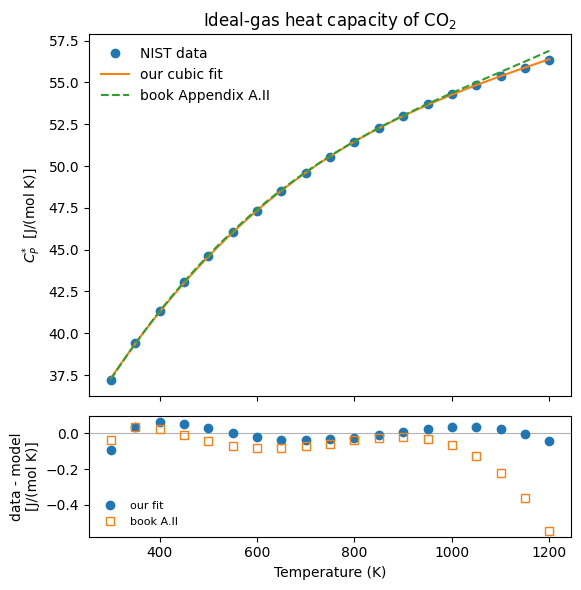

In [5]:
Tp = np.linspace(300, 1200, 300)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(T_data, Cp_data, "o", label="NIST data")
ax1.plot(Tp, cp_fit(Tp), "-",  label="our cubic fit")
ax1.plot(Tp, cp_book(Tp), "--", label="book Appendix A.II")
ax1.set_ylabel(r"$C_P^{*}$  [J/(mol K)]")
ax1.set_title(r"Ideal-gas heat capacity of CO$_2$")
ax1.legend(frameon=False)

ax2.axhline(0, color="0.7", lw=0.8)
ax2.plot(T_data, Cp_data - cp_fit(T_data),  "o", label="our fit")
ax2.plot(T_data, Cp_data - cp_book(T_data), "s", label="book A.II", mfc="none")
ax2.set_ylabel("data - model\n[J/(mol K)]")
ax2.set_xlabel("Temperature (K)")
ax2.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## What to notice

- **The fitted curve tracks the data almost perfectly** — an RMSE of a few hundredths of a J/(mol·K). The book's Appendix A.II curve is also close (within about half a J/(mol·K) across the range).
- **But the individual coefficients differ by 5–25%** — our $a=20.8$ vs the book's $19.8$, and so on. How can that be, if the curves nearly overlap?
  - Polynomial coefficients are **strongly correlated**: a change in the cubic term $d\,T^3$ can be almost cancelled by offsetting changes in the lower terms, so *many* different coefficient sets produce nearly the same curve. The fit is ill-conditioned in the coefficients even when it is well-determined in the prediction.
  - The book's coefficients were regressed over a **different temperature range** and data set than our 300–1200 K NIST points, which shifts them further.
- **Lesson:** compare models by the quantity you care about (the predicted $C_P$, or a derived $\Delta H = \int C_P\,dT$), **not** coefficient-by-coefficient. Nearly equal predictions can come from quite different coefficients.
- **Units and range matter.** $T$ is in kelvin, $C_P^{*}$ in J/(mol·K); trust the fit only over the data range (300–1200 K). Plot `cp_fit` out to 3000 K and watch the $T^3$ term run away.
- **Try it yourself:** change `"CO2"` to another formula in `pure_property.csv`, refit its NIST data, and compare.